## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


4423680/4422102 [==============================] - 1s 0us/step


In [0]:
import tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)

In [0]:
tf.keras.backend.clear_session()

### Find no.of samples are there in training and test datasets

In [0]:
import pandas as pd
import numpy as np

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset

In [7]:
x_train[0,:,:].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
w,h = 28,28
x_train=x_train.reshape(x_train.shape[0],w,h,1)
x_test=x_test.reshape(x_test.shape[0],w,h,1)

In [11]:
x_train.shape

(60000, 28, 28, 1)

In [12]:
x_test.shape

(10000, 28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras import optimizers

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
model = tf.keras.models.Sequential()

In [15]:
#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), padding = 'same', activation='relu', input_shape=(28,28,1)))

#Add second convolutional layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), padding = 'same',activation='relu', input_shape=(28,28,1)))

W0818 10:24:17.485788 140337475897216 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
#Flatten the output
model.add(tf.keras.layers.Flatten())

In [0]:
#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))


In [0]:
#Dense layer2
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
flatten (Flatten)            (None, 25088)             0         
_________________________________________________________________
dense (Dense)                (None, 128)               3211392   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1290      
Total params: 3,222,250
Trainable params: 3,222,250
Non-trainable params: 0
_________________________________________________________________


In [21]:
#Train the model
model.fit(x_train,y_train,
          validation_data=(x_test,y_test),
          epochs=10,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 12s 198us/sample - loss: 0.3576 - acc: 0.8707 - val_loss: 0.3215 - val_acc: 0.8770
Epoch 2/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.2184 - acc: 0.9189 - val_loss: 0.2414 - val_acc: 0.9136
Epoch 3/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.1540 - acc: 0.9419 - val_loss: 0.2521 - val_acc: 0.9136
Epoch 4/10
60000/60000 [==============================] - 8s 139us/sample - loss: 0.1054 - acc: 0.9610 - val_loss: 0.2752 - val_acc: 0.9161
Epoch 5/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.0651 - acc: 0.9764 - val_loss: 0.3089 - val_acc: 0.9161
Epoch 6/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.0413 - acc: 0.9851 - val_loss: 0.4018 - val_acc: 0.9150
Epoch 7/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.0293 - acc: 0.9892 - val_

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

# Must define the input shape in the first layer of the neural network
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(28,28,1))) 
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(28,28,1))) 
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model.add(tf.keras.layers.Dropout(0.25))

#Flatten the output
model.add(tf.keras.layers.Flatten())

#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])


In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 14, 14, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 6272)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               802944    
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1

In [25]:
#Train the model
model.fit(x_train,y_train,          
          validation_data=(x_test,y_test),
          epochs=10,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.3757 - acc: 0.8646 - val_loss: 0.2888 - val_acc: 0.8908
Epoch 2/10
60000/60000 [==============================] - 8s 126us/sample - loss: 0.2436 - acc: 0.9104 - val_loss: 0.2439 - val_acc: 0.9112
Epoch 3/10
60000/60000 [==============================] - 8s 132us/sample - loss: 0.1982 - acc: 0.9254 - val_loss: 0.2518 - val_acc: 0.9144
Epoch 4/10
60000/60000 [==============================] - 8s 128us/sample - loss: 0.1634 - acc: 0.9399 - val_loss: 0.2281 - val_acc: 0.9198
Epoch 5/10
60000/60000 [==============================] - 8s 126us/sample - loss: 0.1356 - acc: 0.9490 - val_loss: 0.2221 - val_acc: 0.9256
Epoch 6/10
60000/60000 [==============================] - 8s 126us/sample - loss: 0.1126 - acc: 0.9577 - val_loss: 0.2645 - val_acc: 0.9190
Epoch 7/10
60000/60000 [==============================] - 8s 127us/sample - loss: 0.0931 - acc: 0.9646 - val_l

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
img_generator= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
                                                                   width_shift_range=0.2,
                                                                   height_shift_range=0.2,
                                                                   horizontal_flip=True)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

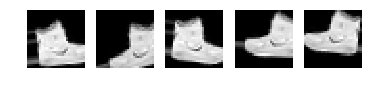

In [27]:
from matplotlib import pyplot as plt
gen = img_generator.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
import keras

In [0]:
from keras.preprocessing.image import ImageDataGenerator

In [35]:
keras.preprocessing.image.ImageDataGenerator(featurewise_center=False, samplewise_center=False, featurewise_std_normalization=False, samplewise_std_normalization=False, zca_whitening=False, zca_epsilon=1e-06, rotation_range=0, width_shift_range=0.0, height_shift_range=0.0, brightness_range=None, shear_range=0.0, zoom_range=0.0, channel_shift_range=0.0, fill_mode='nearest', cval=0.0, horizontal_flip=False, vertical_flip=False, rescale=None, preprocessing_function=None, data_format=None, validation_split=0.0, dtype=None)

In [0]:
datagen = ImageDataGenerator()
    #featurewise_center=True,
    #featurewise_std_normalization=True,
    #rotation_range=20,
    #width_shift_range=0.2,
    #height_shift_range=0.2,
    #horizontal_flip=True)


In [70]:
datagen.fit(x_train)
model.fit_generator(datagen.flow(x_train, y_train, 
                                 batch_size=32),
                                 steps_per_epoch=len(x_train) / 32, 
                                 validation_data=(x_test,y_test),epochs=10)

Epoch 1/10
1563/1562 [==============================] - 21s 13ms/step - loss: 0.2116 - acc: 0.9413 - val_loss: 0.8783 - val_acc: 0.8217
Epoch 2/10
1563/1562 [==============================] - 21s 13ms/step - loss: 0.0792 - acc: 0.9738 - val_loss: 1.1952 - val_acc: 0.7766
Epoch 3/10
1563/1562 [==============================] - 21s 13ms/step - loss: 0.0893 - acc: 0.9701 - val_loss: 0.9203 - val_acc: 0.8193
Epoch 4/10
1563/1562 [==============================] - 20s 13ms/step - loss: 0.0575 - acc: 0.9808 - val_loss: 0.9539 - val_acc: 0.8189
Epoch 5/10
1563/1562 [==============================] - 21s 13ms/step - loss: 0.0668 - acc: 0.9776 - val_loss: 0.9712 - val_acc: 0.8117
Epoch 6/10
1563/1562 [==============================] - 21s 13ms/step - loss: 0.0651 - acc: 0.9774 - val_loss: 0.9112 - val_acc: 0.8208
Epoch 7/10
1563/1562 [==============================] - 21s 13ms/step - loss: 0.0585 - acc: 0.9812 - val_loss: 0.9107 - val_acc: 0.8235
Epoch 8/10
1563/1562 [==========================

###  Report the final train and validation accuracy

In [72]:
score = model.evaluate(x_train, y_train)
print ('/n', 'Test accuracy:', score[1] )

50000/50000 [==============================] - 5s 109us/step
/n Test accuracy: 0.99566


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
import tensorflow as tf
import numpy as np                                
import matplotlib.pyplot as plt
from tensorflow.examples.tutorials.mnist import input_data
import keras as k
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import SGD, Adam
from keras.regularizers import l2
import h5py
from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator

### **Load CIFAR10 dataset**

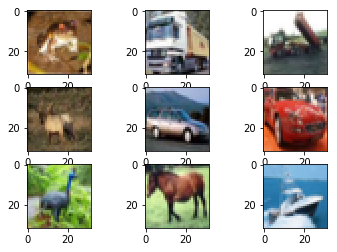

In [78]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
img_rows, img_cols , channels= 32,32,3
for i in range(0,9):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i])
plt.show()

In [0]:
x_train = x_train/255
y_train = y_train/255

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
# set up image augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
    #zoom_range=0.3
    )


### **Prepare/fit the generator.**

In [0]:
datagen.fit(x_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

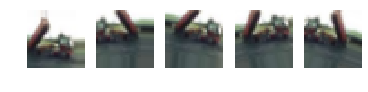

In [83]:
from matplotlib import pyplot as plt
gen = img_generator.flow(x_train[2:3], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()